# Pipeline Completo: Ensemble Baseline → Seleção de Features + Optuna + VotingClassifier

Fluxo: **pré-processamento → ensemble baseline → seleção de features → Optuna → VotingClassifier → melhor par**

Modelos: RandomForest · DecisionTree · KNN · LDA · GaussianNB (calibrado) · GradientBoosting

In [1]:
# ── Bibliotecas padrão ───────────────────────────────────────────
import warnings
from collections import defaultdict
from pathlib import Path
from statistics import mode as stat_mode

# ── Dados / matemática ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paralelismo CPU ──────────────────────────────────────────────
from joblib import Parallel, delayed

# ── Scikit-learn ─────────────────────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LassoCV
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    matthews_corrcoef, precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

# ── Optuna ───────────────────────────────────────────────────────
import optuna

# ── mRMR (opcional) ──────────────────────────────────────────────
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    MRMR_AVAILABLE = False
    print("⚠️  mRMR não disponível. Instale com: pip install mrmr-selection")

# ── Configurações globais ─────────────────────────────────────────
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

print("✅ Imports carregados.")


✅ Imports carregados.


## 1. Carregamento e Pré-processamento

1. Leitura do CSV
2. Tratamento de outliers via IQR capping
3. Remoção de colunas irrelevantes e limpeza de NaN/inf
4. Codificação do label target

In [2]:
# ── 1.1  Carregamento ────────────────────────────────────────────
DATA_PATH = Path("../data/processed/DoS_with_gap_features.csv")
df = pd.read_csv(DATA_PATH)
print(f"Shape original: {df.shape}")

# ── 1.2  Tratamento de outliers (IQR capping) ───────────────────
def cap_outliers_iqr(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Limita valores aos limites IQR (Q1-1.5×IQR, Q3+1.5×IQR) por coluna."""
    df_out = df.copy()
    for col in columns:
        q1, q3 = df_out[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_out[col] = df_out[col].clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)
    return df_out

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_tratado = cap_outliers_iqr(df, numeric_cols)
print(f"Shape após tratamento: {df_tratado.shape}")

# ── 1.3  Seleção de features (remove colunas irrelevantes) ───────
COLUNAS_REMOVER = [
    "frame.time_delta_displayed", "frame.time_epoch", "frame.time_invalid",
    "frame.time_relative", "tcp.srcport", "tcp.dstport",
    "frame.coloring_rule.name", "frame.coloring_rule.string",
    "frame.comment", "frame.comment.expert", "frame.encap_type",
    "frame.file_off", "frame.ignored", "frame.incomplete",
    "frame.interface_id", "frame.interface_name", "frame.link_nr",
    "frame.marked", "frame.md5_hash", "frame.number", "frame.offset_shift",
    "mqtt.msgid", "mqtt.username", "mqtt.passwd",
    "mqtt.willmsg", "mqtt.willtopic",
]

num_df = df_tratado.select_dtypes(include=["int64", "float64"])
X = num_df.drop(columns=[c for c in COLUNAS_REMOVER if c in num_df.columns], errors="ignore")
X = X.fillna(0).replace([np.inf, -np.inf], 0)

# ── 1.4  Encode do label ─────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df_tratado["type"])

print(f"Features: {X.shape[1]} | Amostras: {X.shape[0]}")
print(f"Classes: {le.classes_}  →  {dict(enumerate(le.classes_))}")


Shape original: (94625, 67)
Shape após tratamento: (94625, 67)
Features: 29 | Amostras: 94625
Classes: ['DoS' 'normal']  →  {0: 'DoS', 1: 'normal'}


## 2. Ensemble Baseline (sem seleção de features)

Avaliação rápida com split 70/30 estratificado usando **todos os features** após limpeza.
Objetivo: estabelecer um baseline antes da seleção de features e do Optuna.

Modelos avaliados: RandomForest · DecisionTree · KNN · LDA · GaussianNB (calibrado) · GradientBoosting

Ao final, um VotingClassifier **soft** e um **hard** são treinados com todos os modelos.

Treinando modelos do ensemble baseline…
  ✓ RandomForest          F1=0.9670  Log Loss=0.26702
  ✓ DecisionTree          F1=0.9643  Log Loss=0.58607
  ✓ KNN                   F1=0.9656  Log Loss=0.36967
  ✓ LDA                   F1=0.9268  Log Loss=0.34551
  ✓ GaussianNB_Cal        F1=0.9268  Log Loss=0.23697
  ✓ GradientBoosting      F1=0.9708  Log Loss=0.0793

── Métricas do Ensemble Baseline ─────────────────────────


,accuracy,precision,recall,f1_macro,mcc,log_loss
model,,,,,,
RandomForest,0.96713,0.96773,0.96664,0.96705,0.93437,0.26702
DecisionTree,0.96435,0.96439,0.96421,0.96429,0.92860,0.58607
KNN,0.96569,0.96600,0.96535,0.96562,0.93135,0.36967
LDA,0.92754,0.93575,0.92510,0.92682,0.86078,0.34551
GaussianNB_Cal,0.92754,0.93575,0.92510,0.92682,0.86078,0.23697
GradientBoosting,0.97090,0.97184,0.97027,0.97082,0.94211,0.07930



Treinando VotingClassifier Soft…
Treinando VotingClassifier Hard…

── Voting Classifiers (Soft vs Hard) ─────────────────────


,accuracy,precision,recall,f1_macro,mcc,log_loss
model,,,,,,
VotingClassifier_Soft,0.96971,0.97118,0.96887,0.96960,0.94004,0.09892
VotingClassifier_Hard,0.97002,0.97102,0.96936,0.96993,0.94038,NaN



🏆 Melhor modelo baseline: GradientBoosting
   F1 Macro: 0.97082


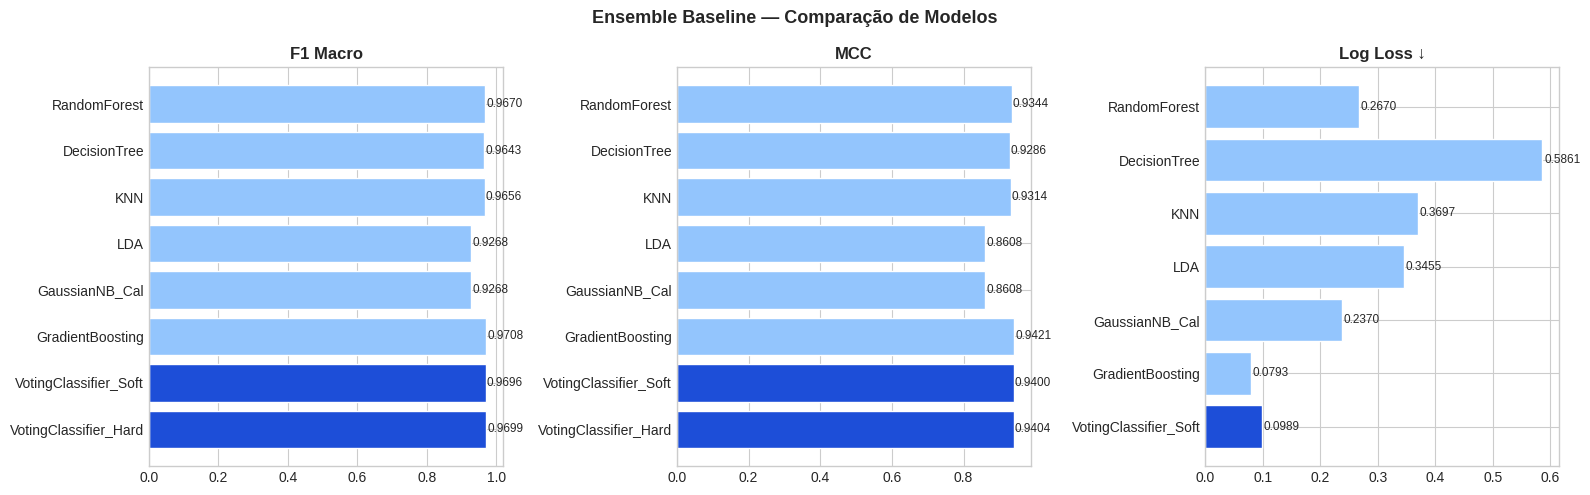

In [3]:
# ── Split estratificado 70/30 ────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_tr_arr, X_te_arr = X_tr.values, X_te.values

# ── Modelos base com hiperparâmetros razoáveis (sem Optuna) ──────
# GradientBoosting usa HistGradientBoosting internamente para
# suportar o tamanho do dataset (~95k amostras) em tempo hábil.
ENSEMBLE_MODELS = {
    "RandomForest":     RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    "DecisionTree":     DecisionTreeClassifier(random_state=42),
    "KNN":              KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "LDA":              LinearDiscriminantAnalysis(),
    "GaussianNB_Cal":   CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                    max_depth=4, random_state=42),
}

def _compute_metrics_simple(model, X_te, y_te, name) -> dict:
    """Calcula métricas para um modelo já treinado."""
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te) if hasattr(model, "predict_proba") else None
    ll = log_loss(y_te, y_proba) if y_proba is not None else np.nan
    return {
        "model":     name,
        "accuracy":  round(accuracy_score(y_te, y_pred), 5),
        "precision": round(precision_score(y_te, y_pred, average="macro", zero_division=0), 5),
        "recall":    round(recall_score(y_te, y_pred, average="macro", zero_division=0), 5),
        "f1_macro":  round(f1_score(y_te, y_pred, average="macro", zero_division=0), 5),
        "mcc":       round(matthews_corrcoef(y_te, y_pred), 5),
        "log_loss":  round(ll, 5) if np.isfinite(ll) else np.nan,
    }

# ── Treina e avalia modelos individuais ──────────────────────────
print("Treinando modelos do ensemble baseline…")
ensemble_rows = []
trained_base = {}
for name, model in ENSEMBLE_MODELS.items():
    model.fit(X_tr_arr, y_tr)
    trained_base[name] = model
    row = _compute_metrics_simple(model, X_te_arr, y_te, name)
    ensemble_rows.append(row)
    print(f"  ✓ {name:20s}  F1={row['f1_macro']:.4f}  Log Loss={row['log_loss']}")

df_ensemble = pd.DataFrame(ensemble_rows).set_index("model")
print("\n── Métricas do Ensemble Baseline ─────────────────────────")
display(df_ensemble)

# ── VotingClassifier Soft ────────────────────────────────────────
print("\nTreinando VotingClassifier Soft…")
vc_soft = VotingClassifier(
    estimators=list(trained_base.items()), voting="soft", n_jobs=-1
)
vc_soft.fit(X_tr_arr, y_tr)
row_soft = _compute_metrics_simple(vc_soft, X_te_arr, y_te, "VotingClassifier_Soft")

# ── VotingClassifier Hard ────────────────────────────────────────
print("Treinando VotingClassifier Hard…")
vc_hard = VotingClassifier(
    estimators=list(trained_base.items()), voting="hard", n_jobs=-1
)
vc_hard.fit(X_tr_arr, y_tr)
row_hard = _compute_metrics_simple(vc_hard, X_te_arr, y_te, "VotingClassifier_Hard")

# ── Tabela comparativa final com os VotingClassifiers ────────────
df_voting_compare = pd.DataFrame([row_soft, row_hard]).set_index("model")
print("\n── Voting Classifiers (Soft vs Hard) ─────────────────────")
display(df_voting_compare)

df_ensemble_full = pd.concat([df_ensemble, df_voting_compare])
best_ensemble_model = df_ensemble_full["f1_macro"].idxmax()
print(f"\n🏆 Melhor modelo baseline: {best_ensemble_model}")
print(f"   F1 Macro: {df_ensemble_full.loc[best_ensemble_model, 'f1_macro']:.5f}")

# ── Gráfico comparativo ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
METRICS_PLOT = ["f1_macro", "mcc", "log_loss"]
LABELS_PLOT  = ["F1 Macro", "MCC", "Log Loss ↓"]
colors_bar = ["#1D4ED8" if "Voting" in m else "#93C5FD" for m in df_ensemble_full.index]

for ax, met, lbl in zip(axes, METRICS_PLOT, LABELS_PLOT):
    vals = df_ensemble_full[met]
    bars = ax.barh(df_ensemble_full.index, vals, color=colors_bar, edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(lbl, fontweight="bold")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f"{v:.4f}" if np.isfinite(v) else "N/A", va="center", fontsize=8.5)

plt.suptitle("Ensemble Baseline — Comparação de Modelos", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Seletores de Características

Cada seletor é **reexecutado dentro de cada fold** para evitar data leakage.  
Ajuste `K_*` para controlar quantas features cada método seleciona.

In [4]:
# ── Quantidade de features por seletor ───────────────────────────
K_MRMR    = 15
K_FISHER  = 15
K_PEARSON = 15
K_TREE    = 15
K_SVC     = 15
K_LASSO   = 15


# ── Fisher Score (variância inter / intra classes) ────────────────
def fisher_score(X: pd.DataFrame, y: np.ndarray) -> np.ndarray:
    """Calcula o Fisher's Score para cada feature numérica."""
    classes = np.unique(y)
    overall_mean = X.mean(axis=0).values
    scores = np.zeros(X.shape[1])
    for i in range(X.shape[1]):
        vals = X.iloc[:, i].values
        between, within = 0.0, 0.0
        for c in classes:
            mask = y == c
            nc = mask.sum()
            if nc > 0:
                mu_c = vals[mask].mean()
                between += nc * (mu_c - overall_mean[i]) ** 2
                within  += nc * vals[mask].var()
        scores[i] = between / within if within > 1e-10 else 0.0
    return scores


# ── Funções de seleção (uma por método) ──────────────────────────
def _selector_functions() -> dict:

    def select_mrmr(X_tr, y_tr):
        if not MRMR_AVAILABLE:
            return []
        try:
            return mrmr_classif(X_tr, y_tr, K=min(K_MRMR, X_tr.shape[1]))
        except Exception as e:
            print(f"[mRMR] erro: {e}")
            return []

    def select_fisher(X_tr, y_tr):
        scores = fisher_score(X_tr, y_tr)
        return (
            pd.DataFrame({"feature": X_tr.columns, "score": scores})
            .sort_values("score", ascending=False)
            .head(min(K_FISHER, len(X_tr.columns)))["feature"].tolist()
        )

    def select_pearson(X_tr, y_tr):
        abs_corr = X_tr.apply(lambda col: abs(np.corrcoef(col, y_tr)[0, 1])).fillna(0)
        return abs_corr.sort_values(ascending=False).head(min(K_PEARSON, len(abs_corr))).index.tolist()

    def select_extratrees(X_tr, y_tr):
        et = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
        et.fit(X_tr, y_tr)
        imp = pd.Series(et.feature_importances_, index=X_tr.columns)
        return imp.sort_values(ascending=False).head(min(K_TREE, X_tr.shape[1])).index.tolist()

    def select_linearsvc_l1(X_tr, y_tr):
        X_sc = StandardScaler().fit_transform(X_tr)
        svc = LinearSVC(C=0.1, penalty="l1", dual=False, max_iter=5000, random_state=42)
        svc.fit(X_sc, y_tr)
        coef = np.mean(np.abs(svc.coef_), axis=0) if svc.coef_.ndim > 1 else np.abs(svc.coef_[0])
        imp = pd.Series(coef, index=X_tr.columns)
        return imp.sort_values(ascending=False).head(min(K_SVC, X_tr.shape[1])).index.tolist()

    def select_lasso(X_tr, y_tr):
        X_sc = StandardScaler().fit_transform(X_tr)
        lasso = LassoCV(cv=3, random_state=42, max_iter=10000, n_jobs=-1)
        lasso.fit(X_sc, y_tr)
        imp = pd.Series(np.abs(lasso.coef_), index=X_tr.columns)
        return imp.sort_values(ascending=False).head(min(K_LASSO, X_tr.shape[1])).index.tolist()

    def select_low_variance(X_tr, y_tr):
        sel = VarianceThreshold(threshold=0.0)
        sel.fit(X_tr)
        return X_tr.columns[sel.get_support(indices=True)].tolist()

    return {
        "mRMR":         select_mrmr,
        "Fisher":       select_fisher,
        "Pearson":      select_pearson,
        "ExtraTrees":   select_extratrees,
        "LinearSVC_L1": select_linearsvc_l1,
        "LassoCV":      select_lasso,
        "LowVariance":  select_low_variance,
    }


selector_funcs = _selector_functions()
print("Seletores disponíveis:", list(selector_funcs.keys()))


Seletores disponíveis: ['mRMR', 'Fisher', 'Pearson', 'ExtraTrees', 'LinearSVC_L1', 'LassoCV', 'LowVariance']


## 4. Objetivos Optuna e Mapa de Modelos

Modelos otimizados: **RandomForest · DecisionTree · KNN · LDA · GaussianNB (calibrado) · GradientBoosting**

Métrica interna: F1-macro em 3-fold CV sobre os dados de treino do fold externo.

| Nota sobre LDA | O hiperparâmetro `shrinkage` só é compatível com solvers `lsqr` e `eigen`. Combinações inválidas são descartadas via `TrialPruned`. |

In [5]:
def _to_array(X):
    """Converte DataFrame → numpy. Zero-copy quando já contíguo."""
    return X.values if isinstance(X, pd.DataFrame) else X


# ── RandomForest ─────────────────────────────────────────────────
def _objective_rf(trial, X_tr, y_tr):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 500, step=50),
        "max_depth":         trial.suggest_categorical("max_depth", [None, 5, 10, 20, 30]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap":         trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42, "n_jobs": -1,
    }
    return cross_val_score(RandomForestClassifier(**params), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()


# ── DecisionTree ─────────────────────────────────────────────────
def _objective_dt(trial, X_tr, y_tr):
    params = {
        "max_depth":         trial.suggest_categorical("max_depth", [None, 3, 5, 10, 20]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 15),
        "criterion":         trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "splitter":          trial.suggest_categorical("splitter", ["best", "random"]),
        "random_state": 42,
    }
    return cross_val_score(DecisionTreeClassifier(**params), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()


# ── KNN ──────────────────────────────────────────────────────────
def _objective_knn(trial, X_tr, y_tr):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 1, 50),
        "weights":     trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric":      trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"]),
        "p":           trial.suggest_int("p", 1, 3),
        "n_jobs": -1,
    }
    return cross_val_score(KNeighborsClassifier(**params), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()


# ── LDA ──────────────────────────────────────────────────────────
# solver='eigen' resolve eigh(Sb, Sw) onde Sw é a matriz de covariância
# intra-classes. Com features correlacionadas (ex: mqtt.len e frame.cap_len),
# Sw fica singular e a fatoração de Cholesky falha com LinAlgError.
# 'svd'  — estável, não usa Sw diretamente, sem suporte a shrinkage.
# 'lsqr' — estável, suporta shrinkage (regulariza Sw, evita singularidade).
# 'eigen' foi removido: numericamente frágil para dados correlacionados.
def _objective_lda(trial, X_tr, y_tr):
    solver    = trial.suggest_categorical("solver", ["svd", "lsqr"])
    shrinkage = trial.suggest_categorical("shrinkage", [None, "auto"])

    if solver == "svd" and shrinkage is not None:
        raise optuna.exceptions.TrialPruned("solver=svd não suporta shrinkage")

    tol = trial.suggest_float("tol", 1e-6, 1e-3, log=True)
    params = {"solver": solver, "shrinkage": shrinkage, "tol": tol}
    try:
        return cross_val_score(
            LinearDiscriminantAnalysis(**params), _to_array(X_tr), y_tr,
            cv=3, scoring="f1_macro", n_jobs=-1,
        ).mean()
    except Exception:
        raise optuna.exceptions.TrialPruned("LDA falhou numericamente")

# ── GaussianNB (com calibração) ───────────────────────────────────
def _objective_gnb(trial, X_tr, y_tr):
    var_smoothing      = trial.suggest_float("var_smoothing", 1e-11, 1e-5, log=True)
    calibration_method = trial.suggest_categorical("calibration_method", ["sigmoid", "isotonic"])
    model = CalibratedClassifierCV(
        GaussianNB(var_smoothing=var_smoothing),
        method=calibration_method, cv=3,
    )
    return cross_val_score(model, _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

def _build_calibrated_gnb(**params) -> CalibratedClassifierCV:
    return CalibratedClassifierCV(
        GaussianNB(var_smoothing=params["var_smoothing"]),
        method=params.get("calibration_method", "isotonic"), cv=3,
    )


# ── GradientBoosting ─────────────────────────────────────────────
def _objective_gb(trial, X_tr, y_tr):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 300, step=50),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":         trial.suggest_int("max_depth", 2, 8),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "random_state": 42,
    }
    return cross_val_score(GradientBoostingClassifier(**params), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()


# ── Mapa: nome → (objetivo, factory/construtor, params_fixos) ────
MODEL_OBJECTIVES = {
    "RandomForest":     (_objective_rf,  RandomForestClassifier,     {"random_state": 42, "n_jobs": -1}),
    "DecisionTree":     (_objective_dt,  DecisionTreeClassifier,     {"random_state": 42}),
    "KNN":              (_objective_knn, KNeighborsClassifier,       {"n_jobs": -1}),
    "LDA":              (_objective_lda, LinearDiscriminantAnalysis, {}),
    "GaussianNB_Cal":   (_objective_gnb, _build_calibrated_gnb,      {}),
    "GradientBoosting": (_objective_gb,  GradientBoostingClassifier, {"random_state": 42}),
}

print("Modelos no pipeline Optuna:", list(MODEL_OBJECTIVES.keys()))


Modelos no pipeline Optuna: ['RandomForest', 'DecisionTree', 'KNN', 'LDA', 'GaussianNB_Cal', 'GradientBoosting']


## 5. Pipeline Core

| Função | Responsabilidade |
|---|---|
| `_tune_one_model` | Roda um study Optuna para um único modelo (picklável para joblib) |
| `tune_models_for_fold` | Otimiza todos os modelos em paralelo (threading) |
| `_aggregate_hyperparams` | Consolida hiperparâmetros de N folds (média/moda) |
| `_aggregate_feature_cols` | Determina conjunto canônico de features por maioria de folds |
| `_compute_metrics` | Calcula métricas para modelo treinado |
| `evaluate_selector_cv` | Loop CV completo: seleciona → tuna → treina → avalia · exporta dataset |

In [6]:
# ── Worker Optuna: um modelo por vez (paralelizável) ─────────────
def _tune_one_model(name, obj_fn, constructor, fixed, X_arr, y_tr, n_trials):
    """
    Executa um study Optuna completo para um único modelo.
    Retorna (nome, instância_configurada, best_params).
    """
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(
        lambda trial: obj_fn(trial, X_arr, y_tr),
        n_trials=n_trials, show_progress_bar=False,
    )
    params = {**study.best_params, **fixed}
    return name, constructor(**params), params.copy()


# ── Tuning paralelo: todos os modelos simultâneos ─────────────────
def tune_models_for_fold(X_tr, y_tr, n_trials=30):
    """
    Otimiza todos os modelos usando APENAS X_tr/y_tr (3-fold interno).
    Paralelismo via threading — 1 thread por modelo.
    """
    X_arr = _to_array(X_tr)
    results = Parallel(n_jobs=len(MODEL_OBJECTIVES), backend="threading")(
        delayed(_tune_one_model)(name, obj_fn, constructor, fixed, X_arr, y_tr, n_trials)
        for name, (obj_fn, constructor, fixed) in MODEL_OBJECTIVES.items()
    )
    instances   = {n: m  for n, m, _ in results}
    best_params = {n: p  for n, _, p in results}
    return instances, best_params


# ── Agregação de hiperparâmetros entre folds ──────────────────────
def _aggregate_hyperparams(params_list):
    if not params_list:
        return {}
    agg = {}
    for key in params_list[0]:
        vals = [p[key] for p in params_list if p.get(key) is not None]
        if not vals:
            agg[key] = None
        elif all(isinstance(v, float) for v in vals):
            agg[key] = float(np.mean(vals))
        elif all(isinstance(v, int) for v in vals):
            agg[key] = int(round(np.mean(vals)))
        else:
            raw = stat_mode(str(v) for v in vals)
            agg[key] = {"None": None, "True": True, "False": False}.get(raw, raw)
    return agg


# ── Conjunto canônico de features (maioria dos folds) ─────────────
def _aggregate_feature_cols(cols_per_fold: list[list]) -> list:
    """
    Retorna as features que aparecem na maioria dos folds (>= 50%).
    Mantém a ordem original de X.columns para consistência.
    """
    from collections import Counter
    n_folds = len(cols_per_fold)
    counter = Counter(col for fold_cols in cols_per_fold for col in fold_cols)
    return [col for col, cnt in counter.items() if cnt >= n_folds / 2]


# ── Cálculo de métricas ───────────────────────────────────────────
def _compute_metrics(model, X_val, y_val):
    y_pred = model.predict(X_val)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
    elif hasattr(model, "decision_function"):
        df_s = model.decision_function(X_val)
        if df_s.ndim == 1:
            df_s = np.vstack([-df_s, df_s]).T
        y_proba = np.exp(df_s) / np.exp(df_s).sum(axis=1, keepdims=True)
    else:
        y_proba = None
    ll = np.nan
    if y_proba is not None:
        try:
            ll = log_loss(y_val, y_proba)
        except Exception:
            pass
    return {
        "accuracy":  accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_val, y_pred, average="macro", zero_division=0),
        "f1":        f1_score(y_val, y_pred, average="macro", zero_division=0),
        "mcc":       matthews_corrcoef(y_val, y_pred),
        "logloss":   ll,
    }


# ── CV estratificado por seletor ──────────────────────────────────
def evaluate_selector_cv(
    selector_name, selector_fn, X_full, y_full,
    cv_splits=5, n_optuna_trials=30, voting="soft",
):
    """
    Por fold:
      1. selector_fn(X_tr, y_tr) → lista de features
      2. Optuna tuna todos os modelos em paralelo (sem ver X_val)
      3. Treina individuais + VotingClassifier soft e hard
      4. Avalia no fold de validação

    Retorna:
        df_soft, df_hard : métricas CV para voting soft e hard
        best_hyperparams : {model: params agregados}
        selector_dataset : X com apenas as features canônicas (maioria dos folds)
        canonical_cols   : lista das features canônicas
    """
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    all_metrics_soft = defaultdict(lambda: defaultdict(list))
    all_metrics_hard = defaultdict(lambda: defaultdict(list))
    fold_hyperparams = defaultdict(list)
    cols_per_fold    = []

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_full, y_full), start=1):
        print(f"  [Fold {fold_idx}/{cv_splits}] {selector_name}…")

        X_tr,  X_val  = X_full.iloc[tr_idx],  X_full.iloc[val_idx]
        y_tr,  y_val  = y_full[tr_idx],        y_full[val_idx]

        cols = selector_fn(X_tr, y_tr)
        if not cols:
            print("    ⚠ Seletor retornou lista vazia — fold ignorado.")
            continue
        cols_per_fold.append(cols)

        X_tr_s, X_val_s = X_tr[cols], X_val[cols]

        model_instances, best_params_fold = tune_models_for_fold(X_tr_s, y_tr, n_trials=n_optuna_trials)
        for name, params in best_params_fold.items():
            fold_hyperparams[name].append(params)

        trained = {}
        for name, model in model_instances.items():
            model.fit(X_tr_s, y_tr)
            trained[name] = model

        # Soft VotingClassifier
        try:
            vc_s = VotingClassifier(estimators=list(trained.items()), voting="soft", n_jobs=-1)
            vc_s.fit(X_tr_s, y_tr)
        except Exception as e:
            print(f"    ⚠ Soft voting falhou ({e}).")
            vc_s = None

        # Hard VotingClassifier
        vc_h = VotingClassifier(estimators=list(trained.items()), voting="hard", n_jobs=-1)
        vc_h.fit(X_tr_s, y_tr)

        # Métricas individuais (acumuladas para ambos os dicts)
        for name, model in trained.items():
            m = _compute_metrics(model, X_val_s, y_val)
            for k, v in m.items():
                all_metrics_soft[name][k].append(v)
                all_metrics_hard[name][k].append(v)

        # Métricas VotingClassifiers
        if vc_s is not None:
            for k, v in _compute_metrics(vc_s, X_val_s, y_val).items():
                all_metrics_soft["VotingClassifier_Soft"][k].append(v)
        for k, v in _compute_metrics(vc_h, X_val_s, y_val).items():
            all_metrics_hard["VotingClassifier_Hard"][k].append(v)

    # Agrega métricas
    def _build_df(all_metrics):
        rows = []
        for model_name, mdict in all_metrics.items():
            row = {"selector": selector_name, "model": model_name}
            for metric, vals in mdict.items():
                finite = [v for v in vals if np.isfinite(v)]
                row[f"{metric}_mean"] = float(np.mean(finite)) if finite else np.nan
                row[f"{metric}_std"]  = float(np.std(finite))  if finite else np.nan
            rows.append(row)
        return pd.DataFrame(rows)

    df_soft = _build_df(all_metrics_soft)
    df_hard = _build_df(all_metrics_hard)

    best_hyperparams = {
        name: _aggregate_hyperparams(plist)
        for name, plist in fold_hyperparams.items()
    }

    # Dataset canônico: features que apareceram em >= 50% dos folds
    canonical_cols = _aggregate_feature_cols(cols_per_fold)
    selector_dataset = X_full[canonical_cols].copy()

    return df_soft, df_hard, best_hyperparams, selector_dataset, canonical_cols

print("✅ Pipeline core definido.")


✅ Pipeline core definido.


## 6. Orquestração, Visualização e Comparação Final

In [7]:
# ── Executa todos os seletores ───────────────────────────────────
def run_all_selectors(selector_funcs, X, y, cv_splits=5, n_optuna_trials=30):
    """
    Itera sobre todos os seletores.
    Retorna:
        df_soft_all, df_hard_all : resultados consolidados (soft e hard)
        hyperparams_all          : {selector: {model: params}}
        selector_datasets        : {selector: (DataFrame, [cols])}
    """
    df_soft_all = pd.DataFrame()
    df_hard_all = pd.DataFrame()
    hyperparams_all   = {}
    selector_datasets = {}

    for sel_name, sel_fn in selector_funcs.items():
        print(f"\n{'═'*60}")
        print(f" Seletor: {sel_name}")
        print(f"{'═'*60}")

        df_s, df_h, best_hp, sel_ds, canon_cols = evaluate_selector_cv(
            sel_name, sel_fn, X, y,
            cv_splits=cv_splits, n_optuna_trials=n_optuna_trials,
        )

        # Exibe métricas do seletor
        print(f"\n  Soft Voting — {sel_name}")
        display(df_s)
        print(f"\n  Hard Voting — {sel_name}")
        display(df_h)
        plot_selector_results(df_s, df_h, f"{sel_name} — Soft vs Hard Voting")

        # Exibe hiperparâmetros e dataset de features
        print(f"\n  Features canônicas ({len(canon_cols)}): {canon_cols}")
        print(f"  Dataset exportado: shape {sel_ds.shape}")

        df_soft_all = pd.concat([df_soft_all, df_s], ignore_index=True)
        df_hard_all = pd.concat([df_hard_all, df_h], ignore_index=True)
        hyperparams_all[sel_name]   = best_hp
        selector_datasets[sel_name] = (sel_ds, canon_cols)

    return df_soft_all, df_hard_all, hyperparams_all, selector_datasets


# ── Gráfico comparativo: soft vs hard por seletor ─────────────────
def plot_selector_results(df_soft, df_hard, title):
    METRICS = [
        ("accuracy_mean",  "Accuracy"),
        ("precision_mean", "Precision"),
        ("recall_mean",    "Recall"),
        ("f1_mean",        "F1 Macro"),
        ("mcc_mean",       "MCC"),
        ("logloss_mean",   "Log Loss ↓"),
    ]

    # Apenas modelos individuais (excluir VotingClassifiers do gráfico principal)
    df_ind = df_soft[~df_soft["model"].str.startswith("Voting")].copy()
    colors = ["#1D4ED8" if "Voting" in m else "#93C5FD" for m in df_ind["model"]]

    ncols, nrows = 3, int(np.ceil(len(METRICS) / 3))
    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4.5 * nrows))
    axes = axes.flatten()

    for ax, (metric, label) in zip(axes, METRICS):
        errs = df_ind[metric.replace("_mean", "_std")]
        bars = ax.barh(df_ind["model"], df_ind[metric], xerr=errs,
                       color=colors, capsize=4, edgecolor="white")
        ax.invert_yaxis()
        ax.set_title(label, fontweight="bold")
        for bar, val in zip(bars, df_ind[metric]):
            ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}" if np.isfinite(val) else "N/A", va="center", fontsize=8.5)

    for j in range(len(METRICS), len(axes)):
        axes[j].axis("off")

    plt.suptitle(title + " (modelos individuais)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ── Heatmap comparativo global ────────────────────────────────────
def plot_selector_comparison(df_all, metric="f1_mean", title_suffix=""):
    if df_all.empty:
        return
    pivot = df_all.pivot_table(index="selector", columns="model", values=metric)
    fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns) * 1.8 + 1), len(pivot) * 0.9 + 1.5))
    im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha="right", fontsize=9)
    ax.set_yticklabels(pivot.index, fontsize=10)
    global_max = np.nanmax(pivot.values)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if np.isfinite(val):
                color = "white" if val > 0.75 * global_max else "black"
                if val == global_max:
                    ax.add_patch(plt.Rectangle((j-.5, i-.5), 1, 1,
                                               linewidth=2.5, edgecolor="#F59E0B", facecolor="none"))
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        color=color, fontsize=8.5, fontweight="bold" if val == global_max else "normal")
    plt.colorbar(im, ax=ax, label=metric)
    ax.set_title(f"Seletores × Modelos — {metric}{title_suffix}  (⭐ = melhor global)",
                 fontsize=11, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()


# ── Melhor par (seletor × modelo) ────────────────────────────────
def find_best_pair(df_soft_all, df_hard_all, hyperparams_all, metric="f1_mean"):
    """
    Compara resultados de soft e hard voting,
    identifica o melhor par (seletor × modelo) e reporta hiperparâmetros.
    """
    results = {}
    for voting_label, df in [("Soft", df_soft_all), ("Hard", df_hard_all)]:
        # Exclui as linhas de VotingClassifier ao buscar melhor modelo individual
        df_ind = df[~df["model"].str.startswith("Voting")]
        if df_ind.empty:
            continue
        best = df_ind.sort_values(metric, ascending=False).iloc[0]
        results[voting_label] = {
            "selector": best["selector"],
            "model":    best["model"],
            "metrics":  {c: best[c] for c in df.columns if c not in ("selector","model")},
        }

    print("\n" + "★"*65)
    print(f"  MELHOR PAR (seletor × modelo)  —  métrica: {metric}")
    print("★"*65)
    for voting_label, res in results.items():
        sel, mod = res["selector"], res["model"]
        params = hyperparams_all.get(sel, {}).get(mod, {})
        print(f"\n  [{voting_label} Voting]")
        print(f"    Seletor : {sel}")
        print(f"    Modelo  : {mod}")
        print(f"    {metric}: {res['metrics'].get(metric, np.nan):.5f}")
        print(f"    Hiperparâmetros:")
        for pk, pv in params.items():
            print(f"      {pk:<28} {pv}")

    print("\n" + "★"*65)
    return results


# ── Tabela de hiperparâmetros ─────────────────────────────────────
def summarize_best_hyperparams(hyperparams_all):
    rows = [
        {"selector": sel, "model": mod, "param": pk, "best_value": pv}
        for sel, mods in hyperparams_all.items()
        for mod, params in mods.items()
        for pk, pv in params.items()
    ]
    return pd.DataFrame(rows)


# ── Exporta datasets de features ──────────────────────────────────
def export_selector_datasets(selector_datasets, output_dir=None):
    """
    Exibe um resumo dos datasets por seletor e salva CSVs se output_dir fornecido.
    Retorna um dict {selector: DataFrame}.
    """
    print("\n── Datasets por Seletor ──────────────────────────────────")
    for sel_name, (ds, cols) in selector_datasets.items():
        print(f"  {sel_name:15s} → {ds.shape[1]} features, {ds.shape[0]} amostras")
        print(f"             Features: {cols}")
        if output_dir is not None:
            path = Path(output_dir) / f"features_{sel_name}.csv"
            ds.to_csv(path, index=False)
            print(f"             Salvo em: {path}")
    return {k: v[0] for k, v in selector_datasets.items()}

print("✅ Orquestração definida.")


✅ Orquestração definida.


## 7. Execução

Ajuste as configurações abaixo e rode a célula. Os resultados de cada seletor aparecem incrementalmente.


════════════════════════════════════════════════════════════
 Seletor: mRMR
════════════════════════════════════════════════════════════
  [Fold 1/5] mRMR…


100%|██████████| 14/14 [00:04<00:00,  2.88it/s]


  [Fold 2/5] mRMR…


100%|██████████| 14/14 [00:03<00:00,  4.18it/s]


  [Fold 3/5] mRMR…


...

100%|██████████| 14/14 [00:03<00:00,  4.03it/s]



  Soft Voting — mRMR


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,mRMR,RandomForest,0.970843,0.000826,0.971574,0.000610,0.970307,0.000928,0.970766,0.000836,0.941880,0.001521,0.076783,0.002930
1,mRMR,DecisionTree,0.970367,0.000874,0.971308,0.000793,0.969735,0.000922,0.970282,0.000880,0.941043,0.001691,0.117031,0.018197
2,mRMR,KNN,0.967863,0.000993,0.968770,0.000770,0.967243,0.001108,0.967771,0.001006,0.936012,0.001851,0.239827,0.121251
3,mRMR,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,mRMR,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,mRMR,GradientBoosting,0.971477,0.000719,0.972359,0.000656,0.970871,0.000756,0.971397,0.000724,0.943229,0.001399,0.077513,0.004294
6,mRMR,VotingClassifier_Soft,0.969089,0.001437,0.970716,0.001264,0.968202,0.001502,0.968976,0.001448,0.938915,0.002762,0.098146,0.002836



  Hard Voting — mRMR


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,mRMR,RandomForest,0.970843,0.000826,0.971574,0.000610,0.970307,0.000928,0.970766,0.000836,0.941880,0.001521,0.076783,0.002930
1,mRMR,DecisionTree,0.970367,0.000874,0.971308,0.000793,0.969735,0.000922,0.970282,0.000880,0.941043,0.001691,0.117031,0.018197
2,mRMR,KNN,0.967863,0.000993,0.968770,0.000770,0.967243,0.001108,0.967771,0.001006,0.936012,0.001851,0.239827,0.121251
3,mRMR,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,mRMR,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,mRMR,GradientBoosting,0.971477,0.000719,0.972359,0.000656,0.970871,0.000756,0.971397,0.000724,0.943229,0.001399,0.077513,0.004294
6,mRMR,VotingClassifier_Hard,0.970980,0.000792,0.971987,0.000615,0.970327,0.000883,0.970895,0.000801,0.942313,0.001467,NaN,NaN


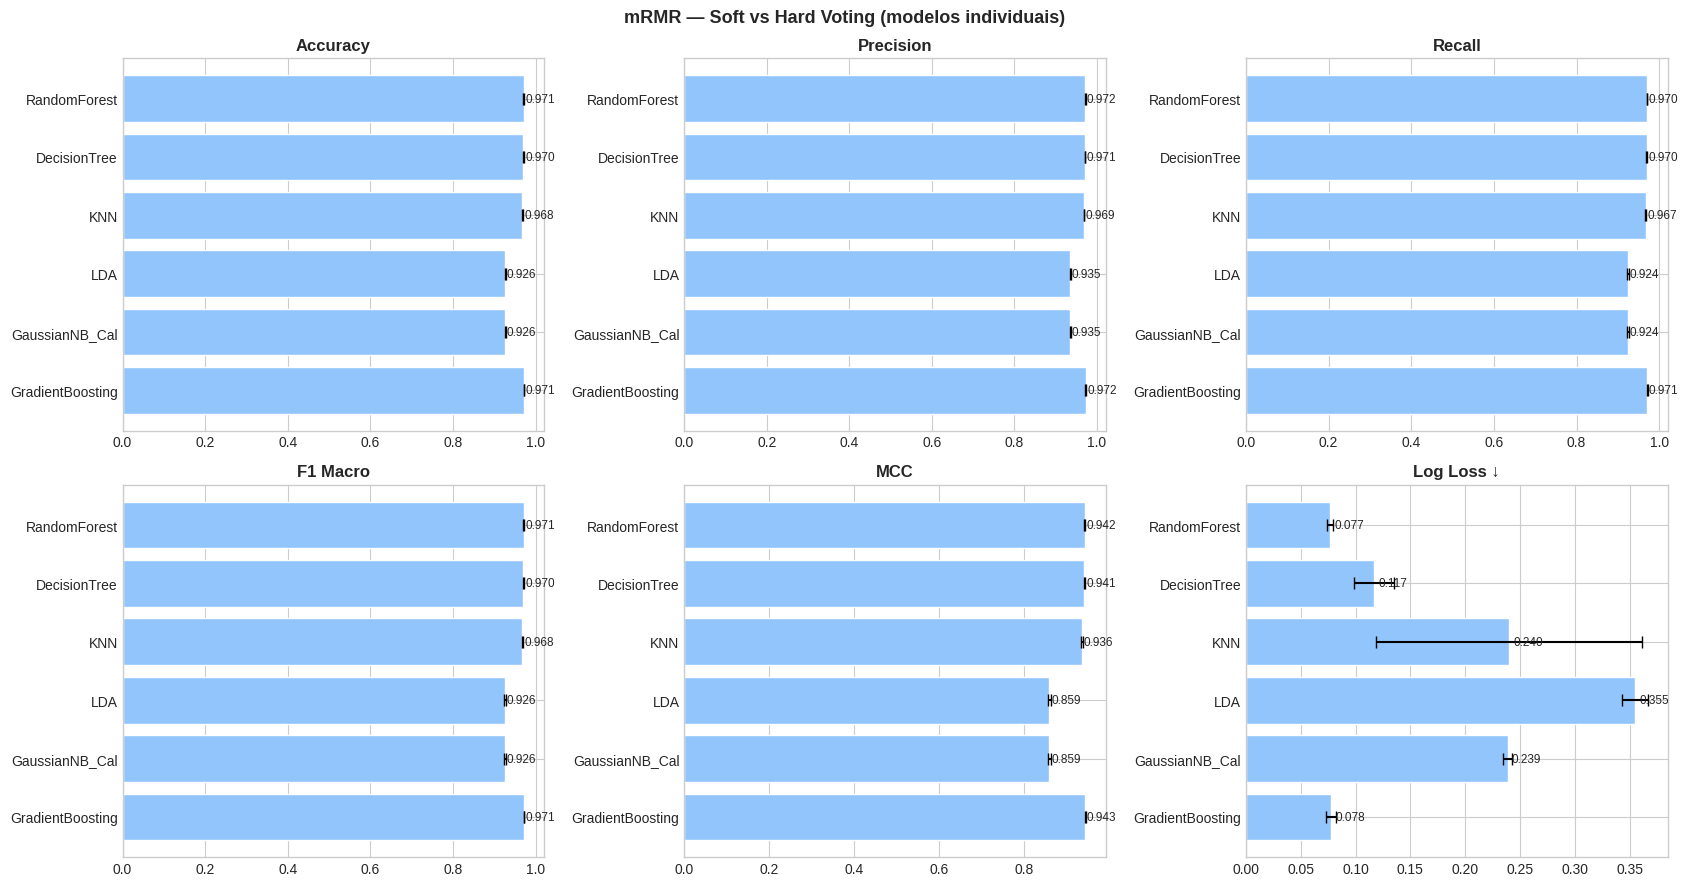


  Features canônicas (14): ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.conack.flags.reserved', 'mqtt.clientid_len', 'connect_gap', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conack.flags.sp', 'mqtt.kalive', 'publish_gap']
  Dataset exportado: shape (94625, 14)

════════════════════════════════════════════════════════════
 Seletor: Fisher
════════════════════════════════════════════════════════════
  [Fold 1/5] Fisher…
  [Fold 2/5] Fisher…
  [Fold 3/5] Fisher…
  [Fold 4/5] Fisher…
  [Fold 5/5] Fisher…

  Soft Voting — Fisher


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,Fisher,RandomForest,0.971065,0.000949,0.971774,0.000838,0.970539,0.001014,0.970990,0.000957,0.942312,0.001825,0.076159,0.003111
1,Fisher,DecisionTree,0.970198,0.001585,0.970949,0.001365,0.969653,0.001690,0.970119,0.001599,0.940601,0.003040,0.148572,0.051259
2,Fisher,KNN,0.967863,0.000993,0.968770,0.000770,0.967243,0.001108,0.967771,0.001006,0.936012,0.001851,0.239827,0.121251
3,Fisher,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,Fisher,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,Fisher,GradientBoosting,0.971361,0.000873,0.972233,0.000840,0.970758,0.000898,0.971281,0.000878,0.942991,0.001726,0.075931,0.002352
6,Fisher,VotingClassifier_Soft,0.969131,0.001579,0.970737,0.001460,0.968250,0.001627,0.969019,0.001588,0.938984,0.003083,0.097750,0.002247



  Hard Voting — Fisher


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,Fisher,RandomForest,0.971065,0.000949,0.971774,0.000838,0.970539,0.001014,0.970990,0.000957,0.942312,0.001825,0.076159,0.003111
1,Fisher,DecisionTree,0.970198,0.001585,0.970949,0.001365,0.969653,0.001690,0.970119,0.001599,0.940601,0.003040,0.148572,0.051259
2,Fisher,KNN,0.967863,0.000993,0.968770,0.000770,0.967243,0.001108,0.967771,0.001006,0.936012,0.001851,0.239827,0.121251
3,Fisher,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,Fisher,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,Fisher,GradientBoosting,0.971361,0.000873,0.972233,0.000840,0.970758,0.000898,0.971281,0.000878,0.942991,0.001726,0.075931,0.002352
6,Fisher,VotingClassifier_Hard,0.970970,0.001578,0.971871,0.001487,0.970356,0.001627,0.970887,0.001586,0.942225,0.003104,NaN,NaN


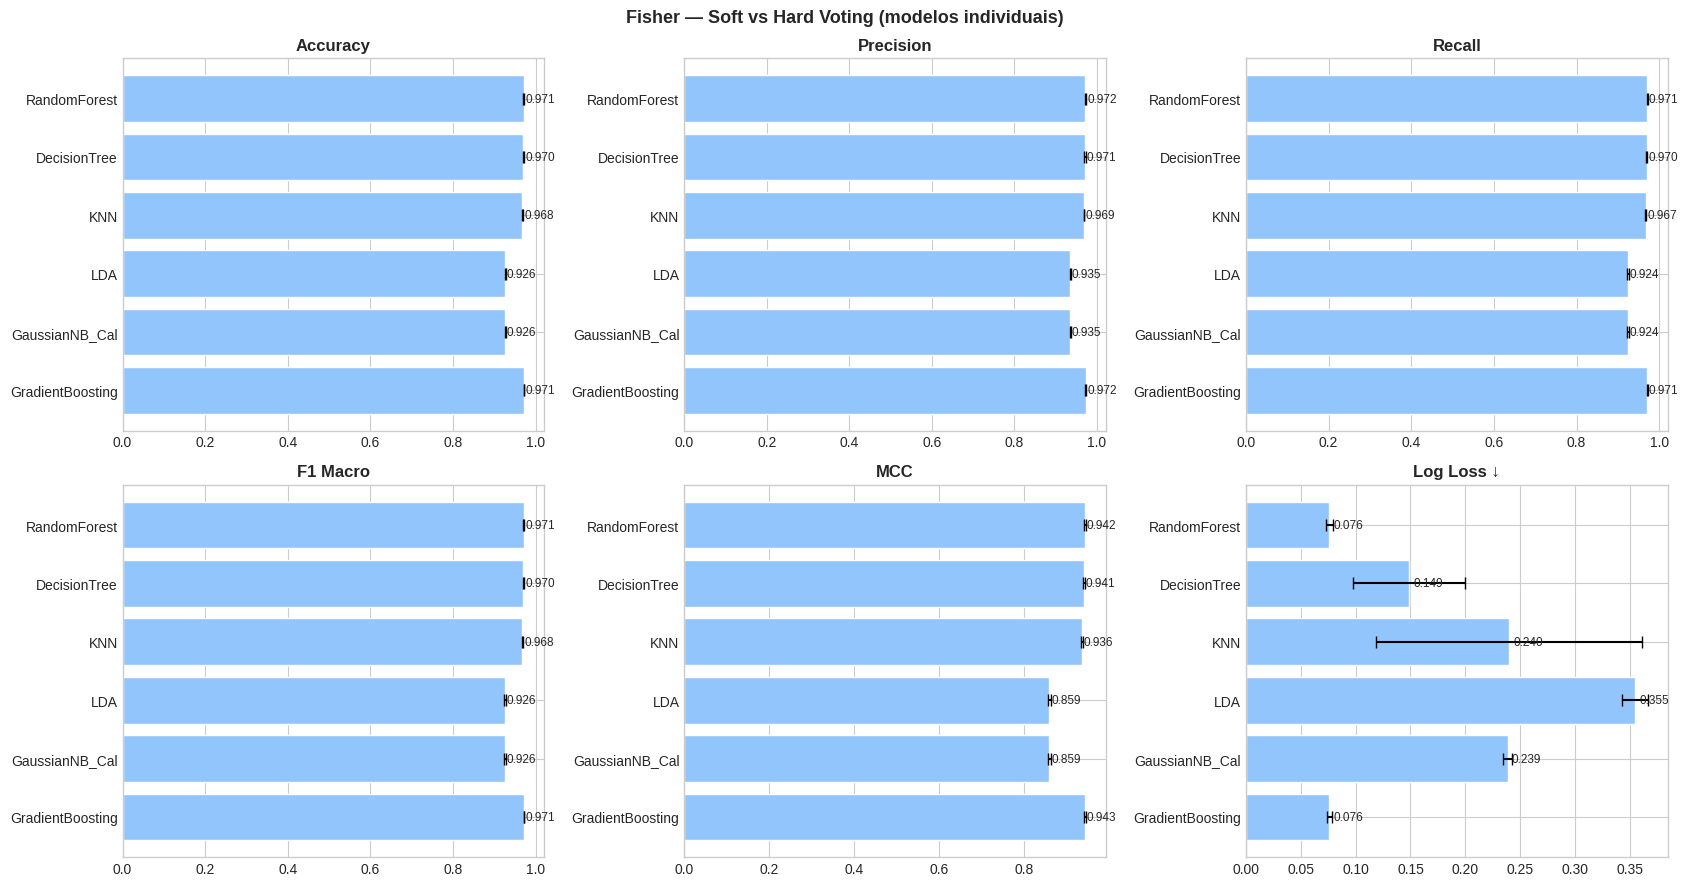


  Features canônicas (15): ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.len', 'frame.cap_len', 'frame.time_delta', 'mqtt.conack.flags.reserved', 'mqtt.conack.val', 'mqtt.conack.flags.sp', 'mqtt.clientid_len', 'mqtt.kalive', 'mqtt.conflag.cleansess', 'connect_gap', 'publish_gap', 'mqtt.conflag.uname']
  Dataset exportado: shape (94625, 15)

════════════════════════════════════════════════════════════
 Seletor: Pearson
════════════════════════════════════════════════════════════
  [Fold 1/5] Pearson…
  [Fold 2/5] Pearson…
  [Fold 3/5] Pearson…
  [Fold 4/5] Pearson…
  [Fold 5/5] Pearson…

  Soft Voting — Pearson


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,Pearson,RandomForest,0.971065,0.000949,0.971774,0.000838,0.970539,0.001014,0.970990,0.000957,0.942312,0.001825,0.076159,0.003111
1,Pearson,DecisionTree,0.970198,0.001585,0.970949,0.001365,0.969653,0.001690,0.970119,0.001599,0.940601,0.003040,0.148572,0.051259
2,Pearson,KNN,0.967863,0.000993,0.968770,0.000770,0.967243,0.001108,0.967771,0.001006,0.936012,0.001851,0.239827,0.121251
3,Pearson,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,Pearson,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,Pearson,GradientBoosting,0.971361,0.000873,0.972233,0.000840,0.970758,0.000898,0.971281,0.000878,0.942991,0.001726,0.075931,0.002352
6,Pearson,VotingClassifier_Soft,0.969131,0.001579,0.970737,0.001460,0.968250,0.001627,0.969019,0.001588,0.938984,0.003083,0.097750,0.002247



  Hard Voting — Pearson


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,Pearson,RandomForest,0.971065,0.000949,0.971774,0.000838,0.970539,0.001014,0.970990,0.000957,0.942312,0.001825,0.076159,0.003111
1,Pearson,DecisionTree,0.970198,0.001585,0.970949,0.001365,0.969653,0.001690,0.970119,0.001599,0.940601,0.003040,0.148572,0.051259
2,Pearson,KNN,0.967863,0.000993,0.968770,0.000770,0.967243,0.001108,0.967771,0.001006,0.936012,0.001851,0.239827,0.121251
3,Pearson,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,Pearson,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,Pearson,GradientBoosting,0.971361,0.000873,0.972233,0.000840,0.970758,0.000898,0.971281,0.000878,0.942991,0.001726,0.075931,0.002352
6,Pearson,VotingClassifier_Hard,0.970970,0.001578,0.971871,0.001487,0.970356,0.001627,0.970887,0.001586,0.942225,0.003104,NaN,NaN


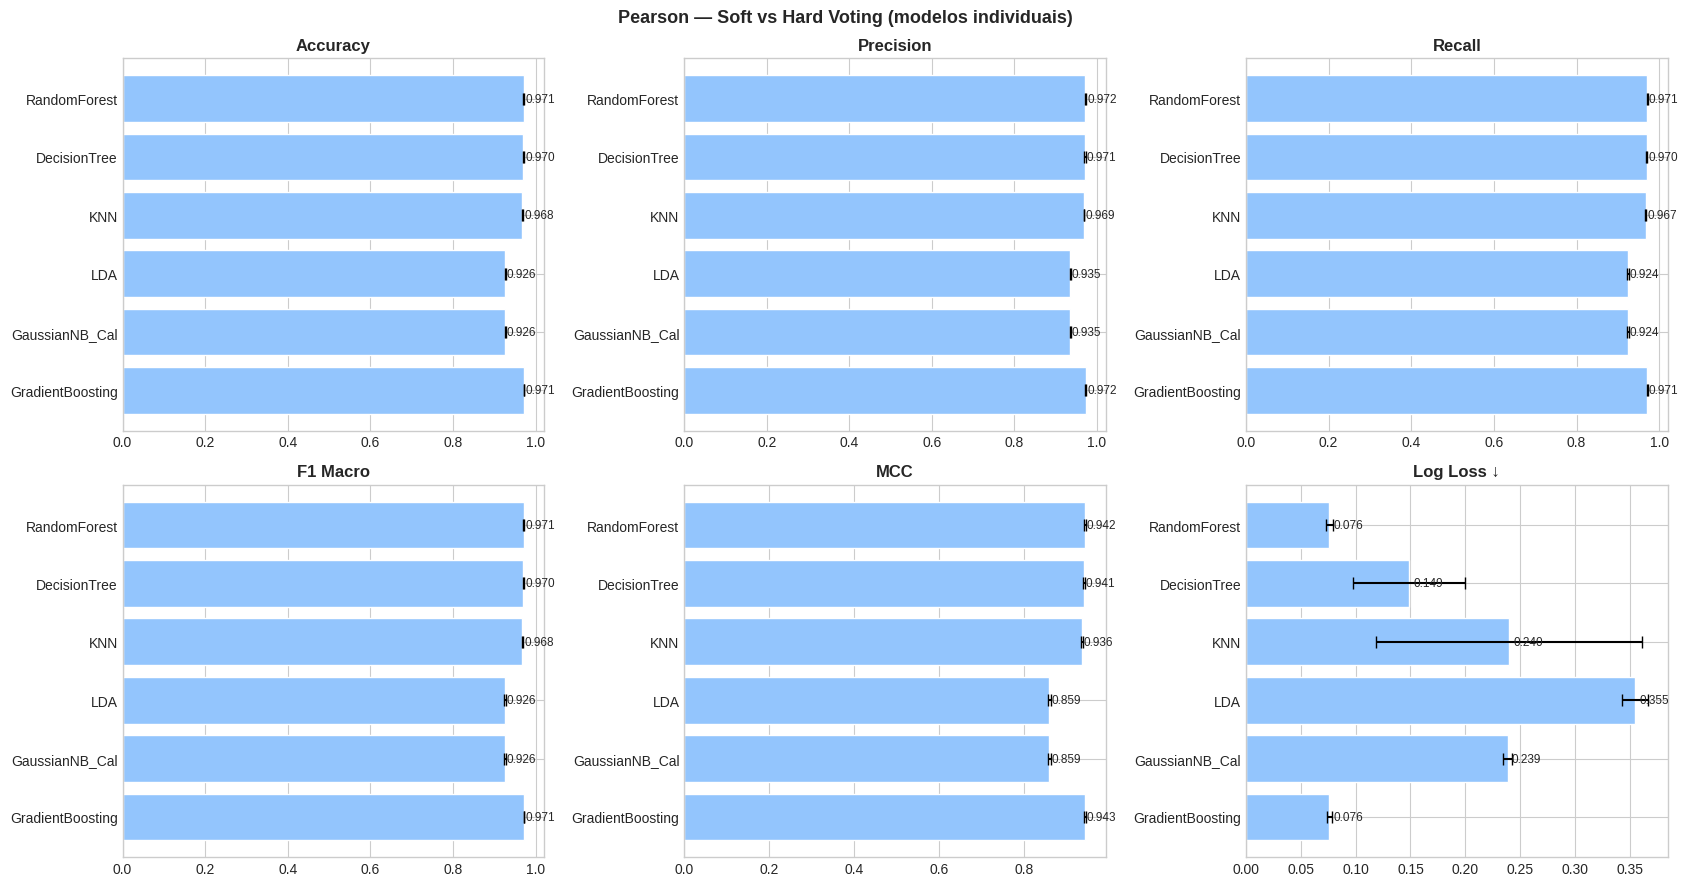


  Features canônicas (15): ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.len', 'frame.cap_len', 'frame.time_delta', 'mqtt.conack.flags.reserved', 'mqtt.conack.val', 'mqtt.conack.flags.sp', 'mqtt.clientid_len', 'mqtt.kalive', 'mqtt.conflag.cleansess', 'connect_gap', 'publish_gap', 'mqtt.conflag.uname']
  Dataset exportado: shape (94625, 15)

════════════════════════════════════════════════════════════
 Seletor: ExtraTrees
════════════════════════════════════════════════════════════
  [Fold 1/5] ExtraTrees…
  [Fold 2/5] ExtraTrees…
  [Fold 3/5] ExtraTrees…
  [Fold 4/5] ExtraTrees…
  [Fold 5/5] ExtraTrees…

  Soft Voting — ExtraTrees


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,ExtraTrees,RandomForest,0.971139,0.000850,0.971881,0.000771,0.970599,0.000905,0.971063,0.000857,0.942478,0.001638,0.076169,0.002487
1,ExtraTrees,DecisionTree,0.970621,0.001144,0.971232,0.001114,0.970138,0.001168,0.970548,0.001148,0.941369,0.002266,0.162353,0.046455
2,ExtraTrees,KNN,0.967863,0.000993,0.968770,0.000770,0.967243,0.001108,0.967771,0.001006,0.936012,0.001851,0.239827,0.121251
3,ExtraTrees,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,ExtraTrees,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,ExtraTrees,GradientBoosting,0.971445,0.000948,0.972326,0.000926,0.970840,0.000967,0.971365,0.000952,0.943164,0.001883,0.076576,0.002508
6,ExtraTrees,VotingClassifier_Soft,0.969310,0.001267,0.970924,0.001122,0.968428,0.001323,0.969199,0.001277,0.939349,0.002442,0.097819,0.002262



  Hard Voting — ExtraTrees


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,ExtraTrees,RandomForest,0.971139,0.000850,0.971881,0.000771,0.970599,0.000905,0.971063,0.000857,0.942478,0.001638,0.076169,0.002487
1,ExtraTrees,DecisionTree,0.970621,0.001144,0.971232,0.001114,0.970138,0.001168,0.970548,0.001148,0.941369,0.002266,0.162353,0.046455
2,ExtraTrees,KNN,0.967863,0.000993,0.968770,0.000770,0.967243,0.001108,0.967771,0.001006,0.936012,0.001851,0.239827,0.121251
3,ExtraTrees,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,ExtraTrees,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,ExtraTrees,GradientBoosting,0.971445,0.000948,0.972326,0.000926,0.970840,0.000967,0.971365,0.000952,0.943164,0.001883,0.076576,0.002508
6,ExtraTrees,VotingClassifier_Hard,0.971350,0.000991,0.972226,0.000909,0.970750,0.001041,0.971270,0.000998,0.942974,0.001928,NaN,NaN


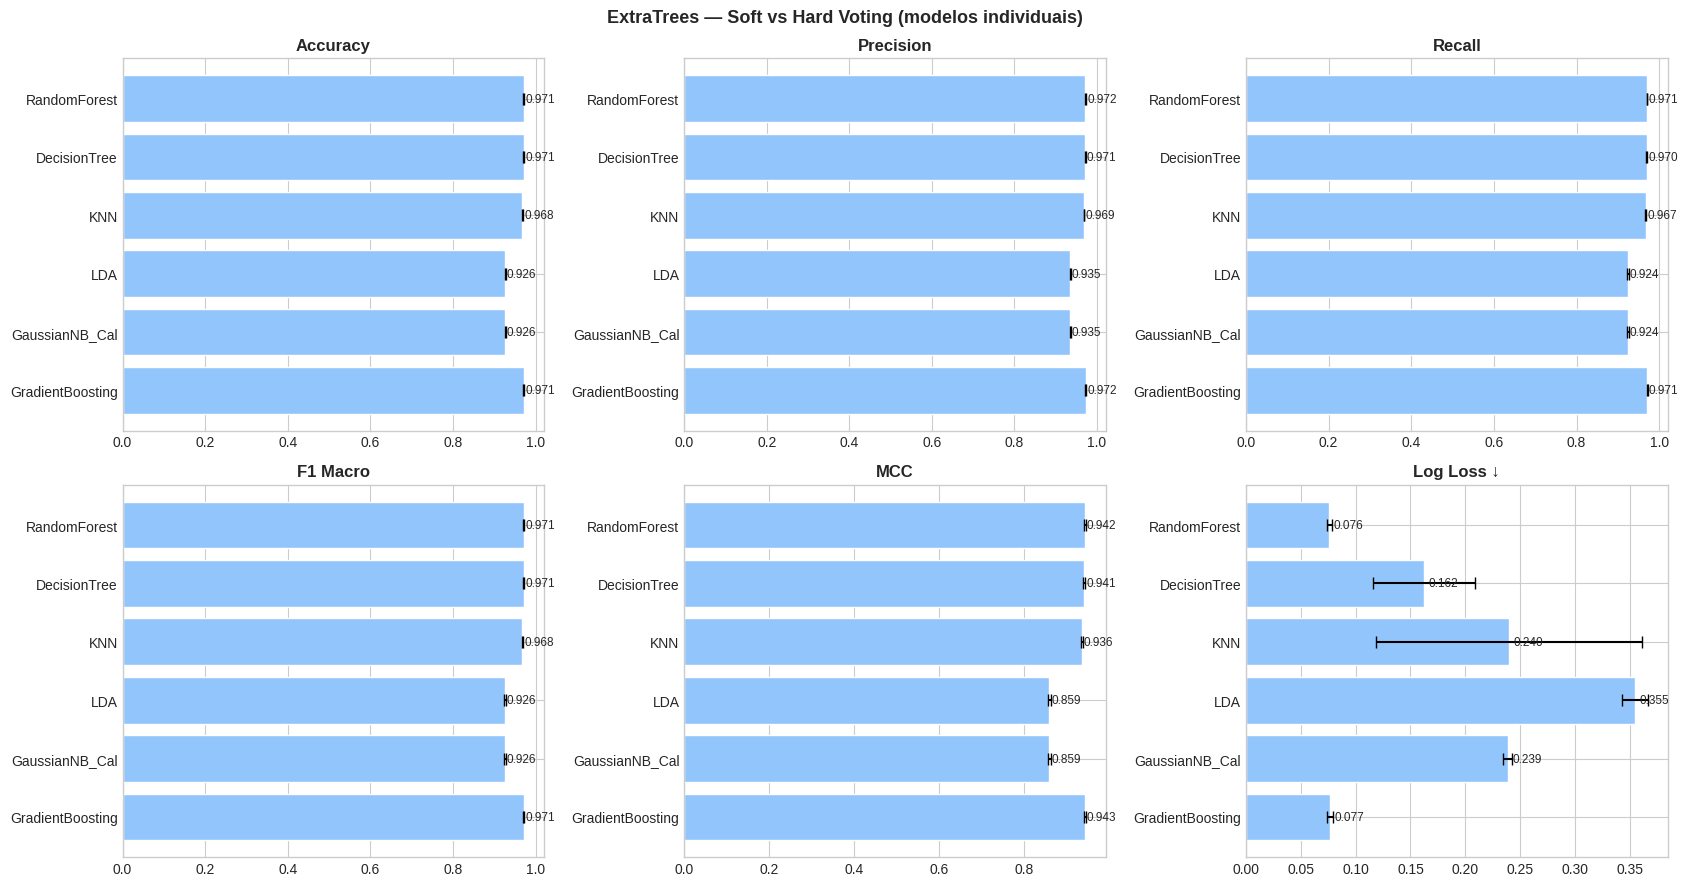


  Features canônicas (15): ['mqtt.topic_len', 'mqtt.len', 'mqtt.msgtype', 'frame.cap_len', 'frame.len', 'frame.time_delta', 'publish_gap', 'mqtt.kalive', 'mqtt.clientid_len', 'mqtt.conflag.cleansess', 'mqtt.conack.flags.reserved', 'mqtt.conack.val', 'mqtt.conack.flags.sp', 'connect_gap', 'mqtt.conflag.uname']
  Dataset exportado: shape (94625, 15)

════════════════════════════════════════════════════════════
 Seletor: LinearSVC_L1
════════════════════════════════════════════════════════════
  [Fold 1/5] LinearSVC_L1…
  [Fold 2/5] LinearSVC_L1…
  [Fold 3/5] LinearSVC_L1…
  [Fold 4/5] LinearSVC_L1…
  [Fold 5/5] LinearSVC_L1…

  Soft Voting — LinearSVC_L1


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LinearSVC_L1,RandomForest,0.971223,0.001131,0.972100,0.001009,0.970624,0.001196,0.971143,0.001139,0.942722,0.002182,0.076373,0.003290
1,LinearSVC_L1,DecisionTree,0.970388,0.000990,0.971037,0.000986,0.969888,0.001010,0.970314,0.000994,0.940924,0.001971,0.123342,0.047390
2,LinearSVC_L1,KNN,0.967884,0.000985,0.968830,0.000750,0.967249,0.001105,0.967791,0.000998,0.936078,0.001827,0.241242,0.120475
3,LinearSVC_L1,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,LinearSVC_L1,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,LinearSVC_L1,GradientBoosting,0.971625,0.000971,0.972509,0.000889,0.971019,0.001014,0.971545,0.000977,0.943526,0.001897,0.076156,0.002877
6,LinearSVC_L1,VotingClassifier_Soft,0.969162,0.001329,0.970773,0.001179,0.968281,0.001387,0.969051,0.001339,0.939051,0.002562,0.097904,0.002448



  Hard Voting — LinearSVC_L1


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LinearSVC_L1,RandomForest,0.971223,0.001131,0.972100,0.001009,0.970624,0.001196,0.971143,0.001139,0.942722,0.002182,0.076373,0.003290
1,LinearSVC_L1,DecisionTree,0.970388,0.000990,0.971037,0.000986,0.969888,0.001010,0.970314,0.000994,0.940924,0.001971,0.123342,0.047390
2,LinearSVC_L1,KNN,0.967884,0.000985,0.968830,0.000750,0.967249,0.001105,0.967791,0.000998,0.936078,0.001827,0.241242,0.120475
3,LinearSVC_L1,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,LinearSVC_L1,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,LinearSVC_L1,GradientBoosting,0.971625,0.000971,0.972509,0.000889,0.971019,0.001014,0.971545,0.000977,0.943526,0.001897,0.076156,0.002877
6,LinearSVC_L1,VotingClassifier_Hard,0.971149,0.001154,0.972017,0.001036,0.970550,0.001213,0.971069,0.001162,0.942566,0.002240,NaN,NaN


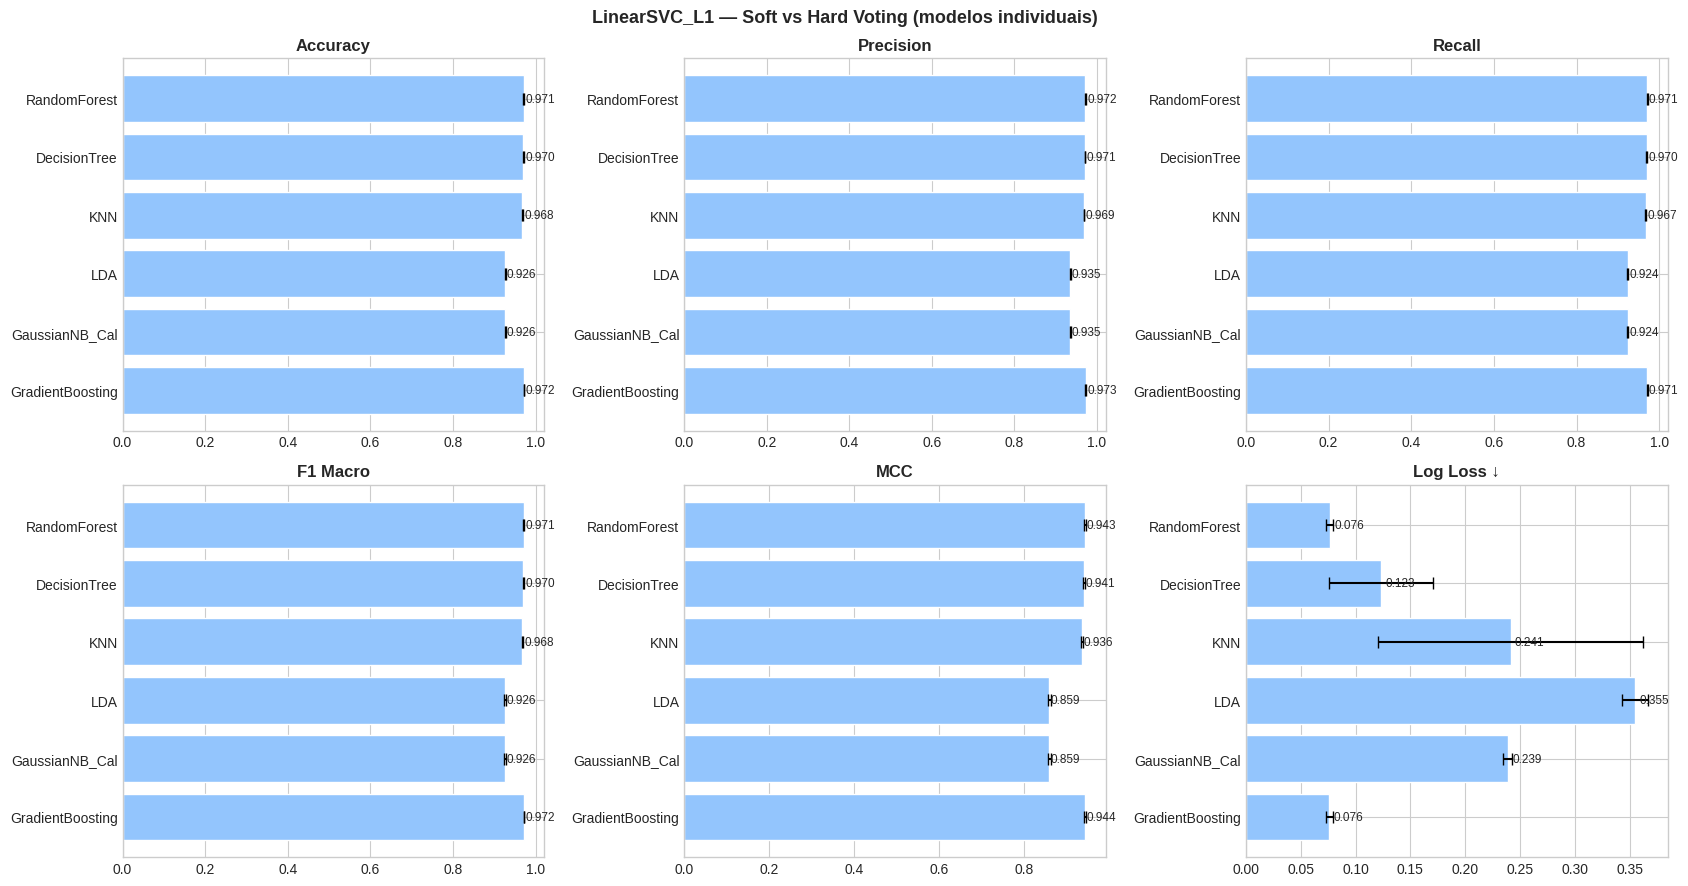


  Features canônicas (15): ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.len', 'frame.time_delta', 'mqtt.conack.flags.reserved', 'mqtt.clientid_len', 'connect_gap', 'publish_gap', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'frame.cap_len', 'mqtt.conflag.uname', 'mqtt.conflag.retain']
  Dataset exportado: shape (94625, 15)

════════════════════════════════════════════════════════════
 Seletor: LassoCV
════════════════════════════════════════════════════════════
  [Fold 1/5] LassoCV…
  [Fold 2/5] LassoCV…
  [Fold 3/5] LassoCV…
  [Fold 4/5] LassoCV…
  [Fold 5/5] LassoCV…

  Soft Voting — LassoCV


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LassoCV,RandomForest,0.971170,0.001037,0.972010,0.000832,0.970594,0.001149,0.971091,0.001049,0.942602,0.001938,0.076891,0.001895
1,LassoCV,DecisionTree,0.970293,0.000859,0.971078,0.000666,0.969732,0.000954,0.970213,0.000869,0.940808,0.001593,0.176879,0.032461
2,LassoCV,KNN,0.967884,0.000985,0.968830,0.000750,0.967249,0.001105,0.967791,0.000998,0.936078,0.001827,0.241242,0.120475
3,LassoCV,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.355559,0.011426
4,LassoCV,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,LassoCV,GradientBoosting,0.971498,0.001043,0.972375,0.000966,0.970894,0.001084,0.971418,0.001049,0.943268,0.002044,0.075569,0.002611
6,LassoCV,VotingClassifier_Soft,0.969353,0.000946,0.970976,0.000784,0.968468,0.001005,0.969241,0.000955,0.939440,0.001787,0.097894,0.002335



  Hard Voting — LassoCV


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LassoCV,RandomForest,0.971170,0.001037,0.972010,0.000832,0.970594,0.001149,0.971091,0.001049,0.942602,0.001938,0.076891,0.001895
1,LassoCV,DecisionTree,0.970293,0.000859,0.971078,0.000666,0.969732,0.000954,0.970213,0.000869,0.940808,0.001593,0.176879,0.032461
2,LassoCV,KNN,0.967884,0.000985,0.968830,0.000750,0.967249,0.001105,0.967791,0.000998,0.936078,0.001827,0.241242,0.120475
3,LassoCV,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.355559,0.011426
4,LassoCV,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,LassoCV,GradientBoosting,0.971498,0.001043,0.972375,0.000966,0.970894,0.001084,0.971418,0.001049,0.943268,0.002044,0.075569,0.002611
6,LassoCV,VotingClassifier_Hard,0.971054,0.001034,0.971986,0.000888,0.970431,0.001108,0.970971,0.001042,0.942415,0.001972,NaN,NaN


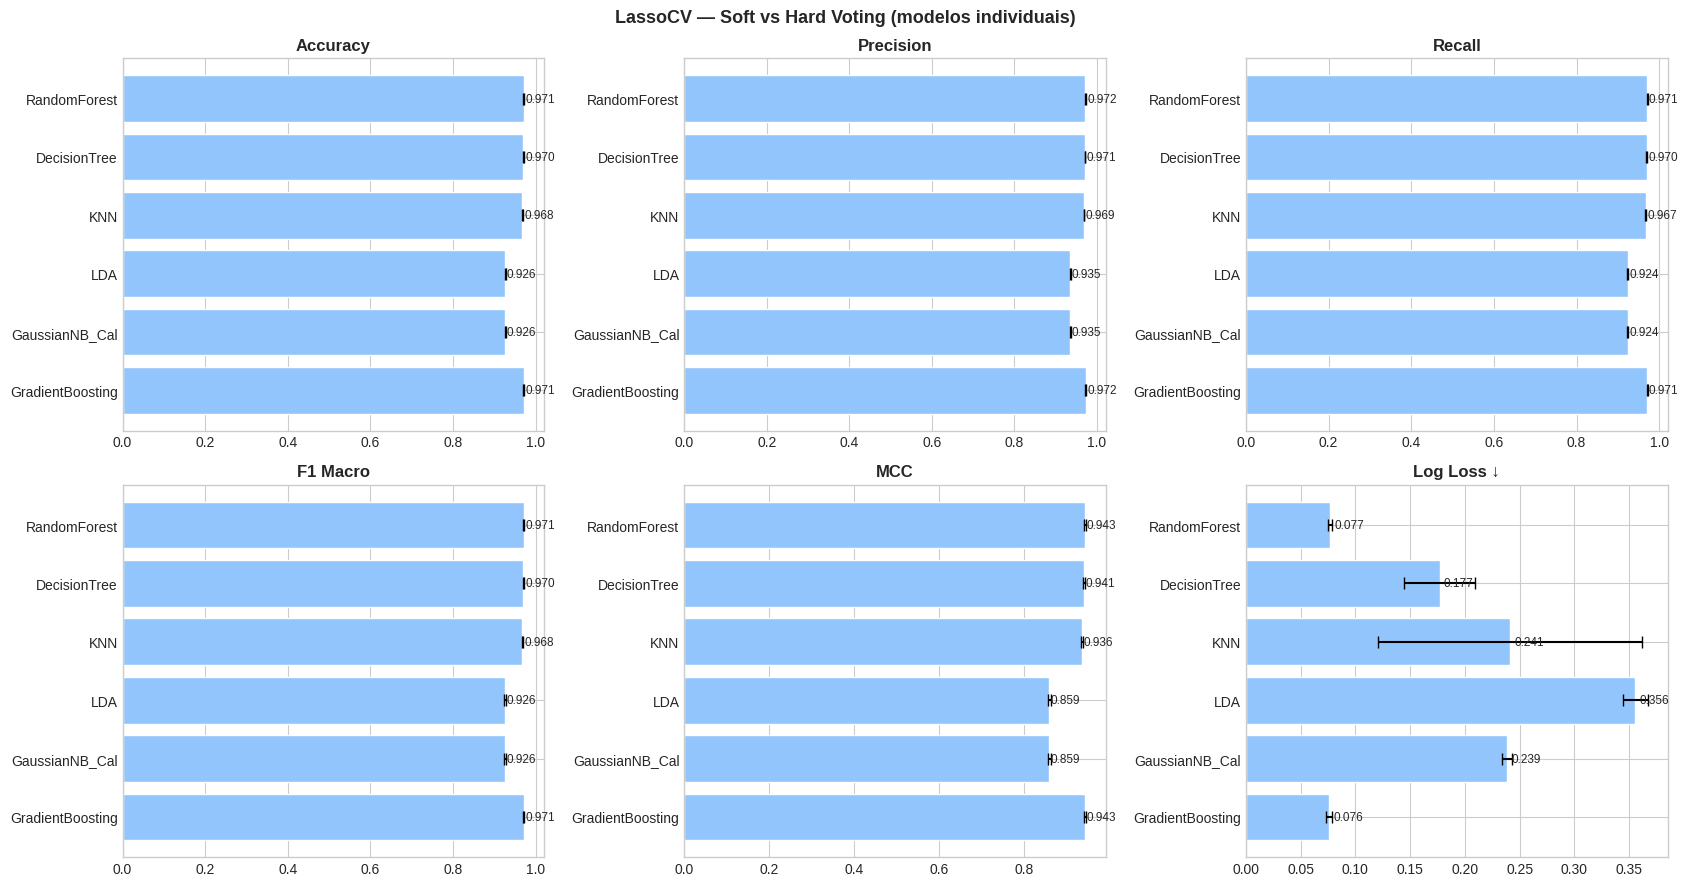


  Features canônicas (15): ['mqtt.len', 'mqtt.topic_len', 'frame.cap_len', 'frame.time_delta', 'mqtt.clientid_len', 'mqtt.conack.flags.reserved', 'connect_gap', 'publish_gap', 'mqtt.conack.flags.sp', 'frame.len', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.passwd', 'mqtt.conflag.uname', 'mqtt.conflag.retain']
  Dataset exportado: shape (94625, 15)

════════════════════════════════════════════════════════════
 Seletor: LowVariance
════════════════════════════════════════════════════════════
  [Fold 1/5] LowVariance…
  [Fold 2/5] LowVariance…
  [Fold 3/5] LowVariance…
  [Fold 4/5] LowVariance…
  [Fold 5/5] LowVariance…

  Soft Voting — LowVariance


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LowVariance,RandomForest,0.971128,0.000771,0.971913,0.000644,0.970568,0.000848,0.971051,0.000779,0.942481,0.001458,0.075692,0.002096
1,LowVariance,DecisionTree,0.969596,0.001147,0.970608,0.000978,0.968944,0.001247,0.969506,0.001159,0.939550,0.002161,0.124773,0.050767
2,LowVariance,KNN,0.967863,0.000993,0.968770,0.000770,0.967243,0.001108,0.967771,0.001006,0.936012,0.001851,0.239827,0.121251
3,LowVariance,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,LowVariance,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,LowVariance,GradientBoosting,0.971466,0.000830,0.972349,0.000803,0.970860,0.000852,0.971386,0.000834,0.943208,0.001643,0.076512,0.002325
6,LowVariance,VotingClassifier_Soft,0.969247,0.001236,0.970856,0.001054,0.968367,0.001305,0.969136,0.001246,0.939220,0.002353,0.098046,0.002221



  Hard Voting — LowVariance


,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LowVariance,RandomForest,0.971128,0.000771,0.971913,0.000644,0.970568,0.000848,0.971051,0.000779,0.942481,0.001458,0.075692,0.002096
1,LowVariance,DecisionTree,0.969596,0.001147,0.970608,0.000978,0.968944,0.001247,0.969506,0.001159,0.939550,0.002161,0.124773,0.050767
2,LowVariance,KNN,0.967863,0.000993,0.968770,0.000770,0.967243,0.001108,0.967771,0.001006,0.936012,0.001851,0.239827,0.121251
3,LowVariance,LDA,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.354727,0.011488
4,LowVariance,GaussianNB_Cal,0.926436,0.001668,0.935072,0.001449,0.923924,0.001714,0.925674,0.001703,0.858924,0.003145,0.238597,0.004254
5,LowVariance,GradientBoosting,0.971466,0.000830,0.972349,0.000803,0.970860,0.000852,0.971386,0.000834,0.943208,0.001643,0.076512,0.002325
6,LowVariance,VotingClassifier_Hard,0.971107,0.000693,0.971986,0.000599,0.970504,0.000752,0.971026,0.000700,0.942489,0.001321,NaN,NaN


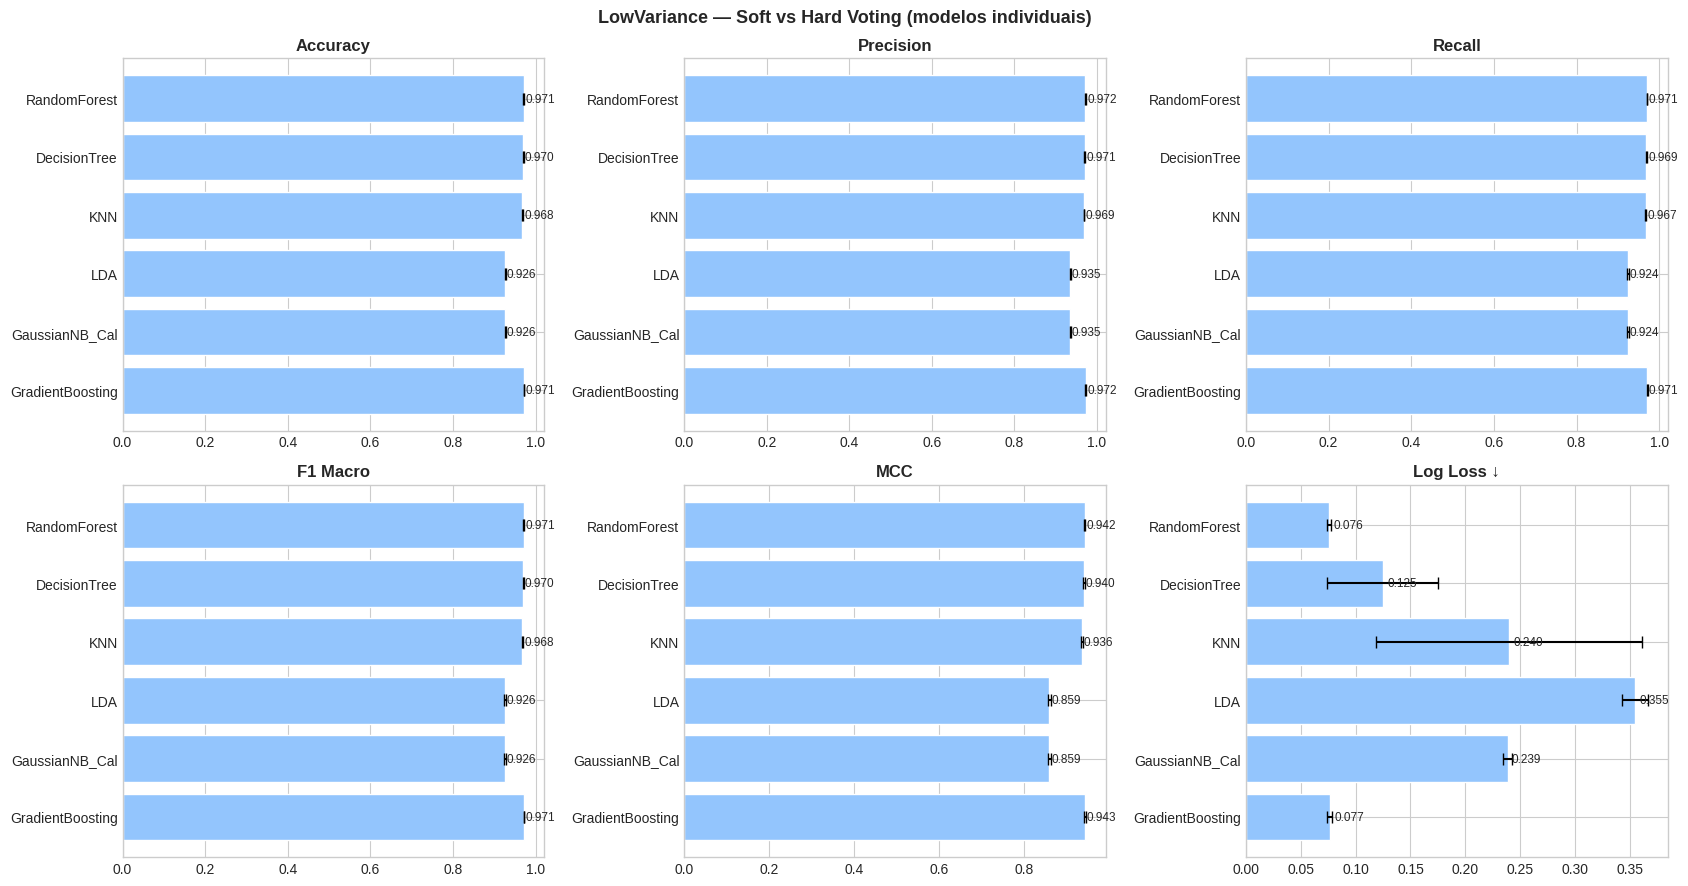


  Features canônicas (14): ['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'publish_gap', 'connect_gap']
  Dataset exportado: shape (94625, 14)

─────────────────────────────────────────────────────────────────
 COMPARAÇÃO GLOBAL — Soft Voting
─────────────────────────────────────────────────────────────────


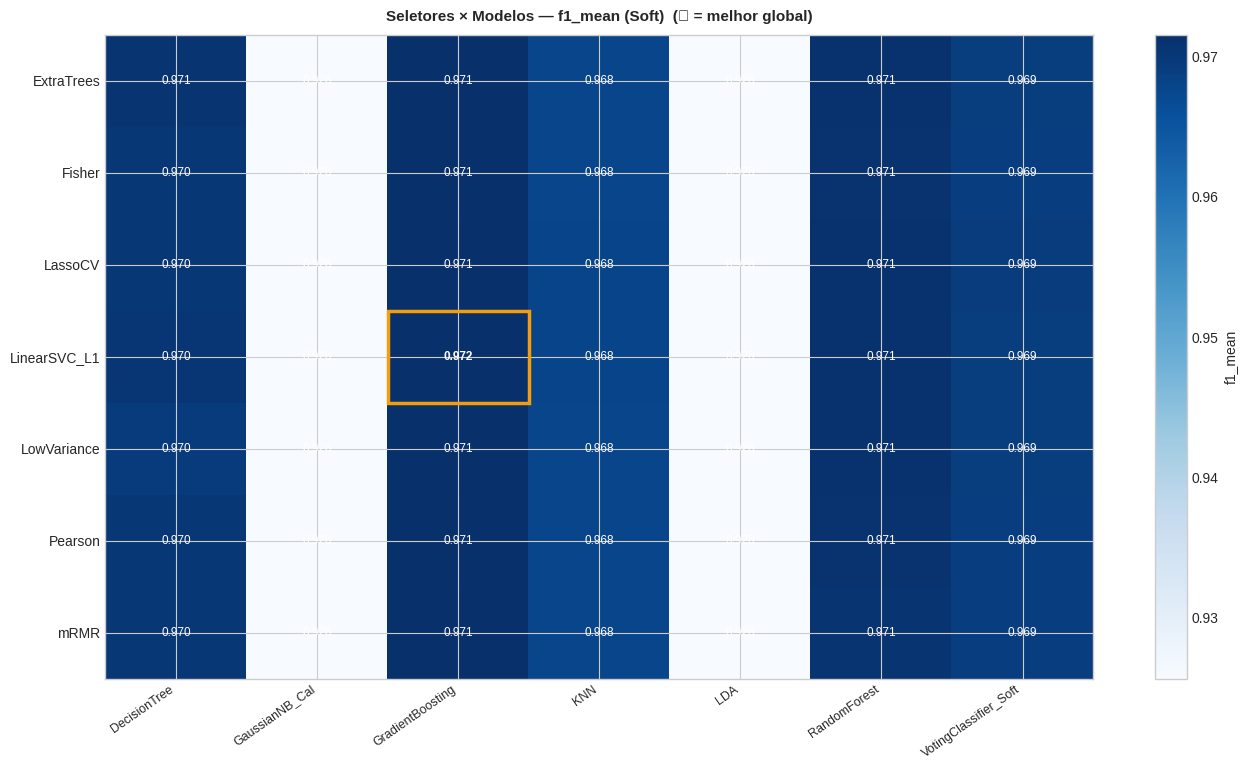


─────────────────────────────────────────────────────────────────
 COMPARAÇÃO GLOBAL — Hard Voting
─────────────────────────────────────────────────────────────────


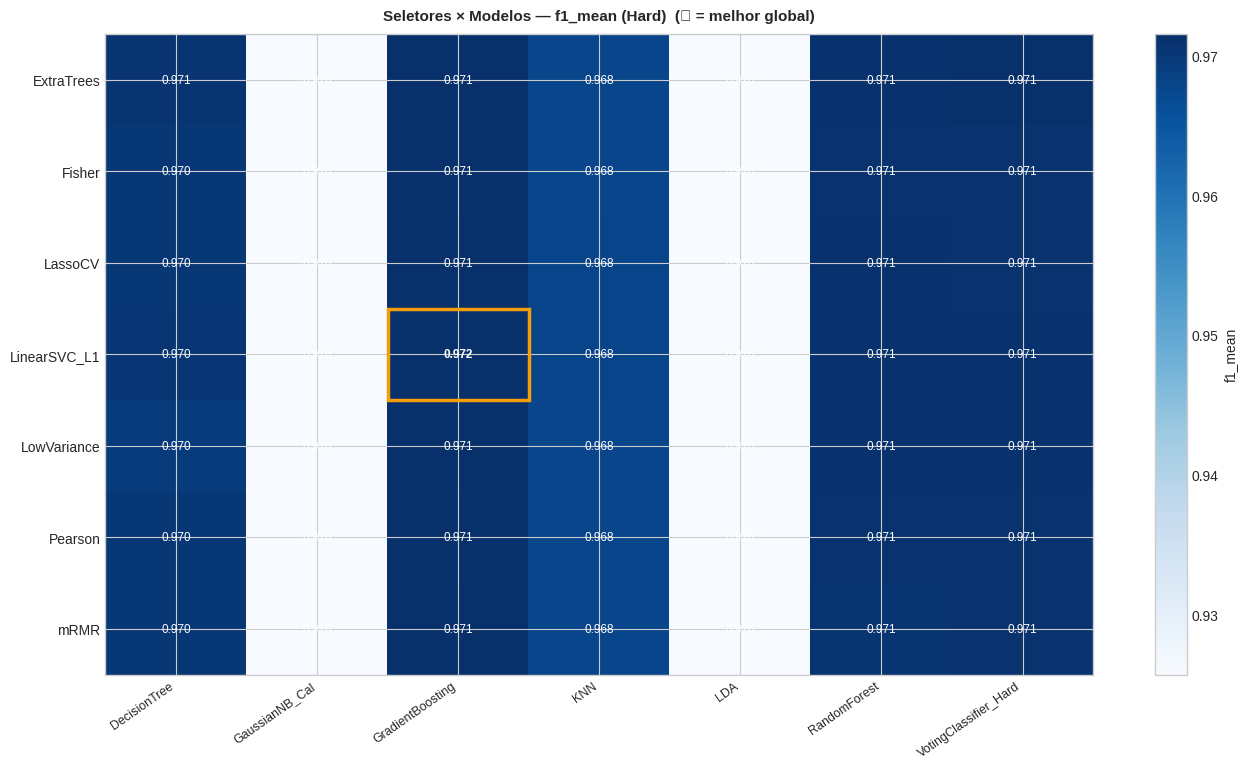


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  MELHOR PAR (seletor × modelo)  —  métrica: f1_mean
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

  [Soft Voting]
    Seletor : LinearSVC_L1
    Modelo  : GradientBoosting
    f1_mean: 0.97155
    Hiperparâmetros:
      n_estimators                 210
      learning_rate                0.04599227164397557
      max_depth                    5
      min_samples_split            5
      min_samples_leaf             7
      subsample                    0.8175427664586072
      random_state                 42

  [Hard Voting]
    Seletor : LinearSVC_L1
    Modelo  : GradientBoosting
    f1_mean: 0.97155
    Hiperparâmetros:
      n_estimators                 210
      learning_rate                0.04599227164397557
      max_depth                    5
      min_samples_split            5
      min_samples_leaf             7
      subsample                    0.8175427664586072
      random_state      

,selector,model,param,best_value
0,mRMR,RandomForest,n_estimators,300
1,mRMR,RandomForest,max_depth,13
2,mRMR,RandomForest,min_samples_split,12
3,mRMR,RandomForest,min_samples_leaf,7
4,mRMR,RandomForest,max_features,log2
...,...,...,...,...
219,LowVariance,GradientBoosting,max_depth,5
220,LowVariance,GradientBoosting,min_samples_split,5
221,LowVariance,GradientBoosting,min_samples_leaf,7
222,LowVariance,GradientBoosting,subsample,0.822625



── Datasets por Seletor ──────────────────────────────────
  mRMR            → 14 features, 94625 amostras
             Features: ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.conack.flags.reserved', 'mqtt.clientid_len', 'connect_gap', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conack.flags.sp', 'mqtt.kalive', 'publish_gap']
             Salvo em: ../data/processed/feature_sets/features_mRMR.csv
  Fisher          → 15 features, 94625 amostras
             Features: ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.len', 'frame.cap_len', 'frame.time_delta', 'mqtt.conack.flags.reserved', 'mqtt.conack.val', 'mqtt.conack.flags.sp', 'mqtt.clientid_len', 'mqtt.kalive', 'mqtt.conflag.cleansess', 'connect_gap', 'publish_gap', 'mqtt.conflag.uname']
             Salvo em: ../data/processed/feature_sets/features_Fisher.csv
  Pearson         → 15 features, 94625 amostras
             Features: ['mqtt.len', 'mqtt.msgtype', 'mqtt.

In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              CONFIGURAÇÃO DA EXECUÇÃO                       ║
# ╚══════════════════════════════════════════════════════════════╝
CV_SPLITS        = 5
N_OPTUNA_TRIALS  = 30
RANK_METRIC      = "f1_mean"

# Pasta para salvar os CSVs de features por seletor (None = não salva)
OUTPUT_DIR = "../data/processed/feature_sets"    # ex: "../data/processed/feature_sets"

# ── Executa todos os seletores ────────────────────────────────────
df_soft_all, df_hard_all, hyperparams_all, selector_datasets = run_all_selectors(
    selector_funcs  = selector_funcs,
    X               = X,
    y               = y,
    cv_splits       = CV_SPLITS,
    n_optuna_trials = N_OPTUNA_TRIALS,
)

# ── Heatmaps comparativos globais ─────────────────────────────────
print("\n" + "─"*65)
print(" COMPARAÇÃO GLOBAL — Soft Voting")
print("─"*65)
plot_selector_comparison(df_soft_all, metric=RANK_METRIC, title_suffix=" (Soft)")

print("\n" + "─"*65)
print(" COMPARAÇÃO GLOBAL — Hard Voting")
print("─"*65)
plot_selector_comparison(df_hard_all, metric=RANK_METRIC, title_suffix=" (Hard)")

# ── Melhor par e hiperparâmetros ──────────────────────────────────
best_results = find_best_pair(
    df_soft_all, df_hard_all, hyperparams_all, metric=RANK_METRIC
)

# ── Tabela completa de hiperparâmetros ────────────────────────────
print("\n── Hiperparâmetros agregados por (seletor × modelo) ────────")
display(summarize_best_hyperparams(hyperparams_all))

# ── Datasets de features selecionadas ────────────────────────────
selector_dfs = export_selector_datasets(selector_datasets, output_dir=OUTPUT_DIR)

# ── Resumo final ─────────────────────────────────────────────────
print("\n" + "═"*65)
print(" RESUMO FINAL")
print("═"*65)
for voting_label, res in best_results.items():
    f1_val = res["metrics"].get(RANK_METRIC, np.nan)
    print(f"  [{voting_label}] Melhor seletor : {res['selector']}")
    print(f"         Melhor modelo  : {res['model']}")
    print(f"         {RANK_METRIC}      : {f1_val:.5f}")
    print()
